In [4]:
import os
import cv2
import pywt
import pandas as pd
import numpy as np
import seaborn as sn
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import hog
from sklearn.metrics import classification_report, confusion_matrix
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [5]:
def cnn_augmentation(img):
    h, w = img.shape[:2]

    # --- 1. Mild rotation (clockwise, +5°) ---
    # Smaller than 7° to preserve anatomical alignment
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # --- 2. Mild zoom (1.05x) with center crop ---
    zf = 1.05  # reduced zoom, avoids cutting tumor edges
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # --- 3. Fixed gamma correction (gentle brightening) ---
    gamma = 1.1  # slightly less aggressive than 1.15
    img = np.power(img / 255.0, gamma) * 255
    img = np.clip(img, 0, 255).astype(np.uint8)

    # --- 4. Fixed noise pattern (low amplitude sinusoid) ---
    # Lower amplitude (±3) so texture is altered but not dominant
    yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing="ij")
    noise = 3 * np.sin(0.05 * xx + 0.05 * yy)  # smoother, deterministic pattern
    img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return img


def rf_augmentation(img):
    img = img.astype(np.float32) / 255.0
    h, w = img.shape[:2]

    # same zoom
    zf = 1.012
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    sy, sx = (zh - h)//2, (zw - w)//2
    img = img[sy:sy+h, sx:sx+w]

    # gamma a bit stronger (1.06)
    gamma = 1.06
    img = np.power(img, gamma)

    # CLAHE stronger (clipLimit=2.0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = (clahe.apply((img*255).astype(np.uint8)) / 255.0).astype(np.float32)

    # no noise
    return (img*255).astype(np.uint8)


def svm_augmentation(img):
    h, w = img.shape[:2]

    # Fixed rotation (+7°)
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), 7, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Zoom 1.08x
    zf = 1.08
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y, start_x = (zh-h)//2, (zw-w)//2
    img = img[start_y:start_y+h, start_x:start_x+w]

    # Gamma correction (1.15 → darker)
    img = np.power(img/255.0, 1.15) * 255

    # Gaussian blur
    img = cv2.GaussianBlur(img.astype(np.uint8), (5,5), 0)

    # Horizontal flip
    img = cv2.flip(img, 1)

    return img


def knn_augmentation(img, target_size=(200, 200)):
    h, w = img.shape[:2]
    # --- Step 1: Normalize intensity [0,1] ---
    img = img.astype(np.float32) / 255.0
    # --- Step 2: Small fixed rotation (3° clockwise) ---
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), 3, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)
    # --- Step 3: Fixed zoom (1.02x) ---
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]
    # --- Step 4: Fixed contrast stretch ---
    img = cv2.normalize(img, None, alpha=0, beta=1.0, norm_type=cv2.NORM_MINMAX)
    # --- Step 5: Fixed gentle denoise ---
    img = cv2.GaussianBlur(img, (3, 3), 0)
    # --- Step 6: Resize to fixed target size ---
    img = cv2.resize(img, target_size)
    # --- Step 7: Convert back to 8-bit grayscale ---
    img = (img * 255).astype(np.uint8)
    return img



def LR_augmentation(img):

    # Convert to float [0,1]
    img = img.astype(np.float32) / 255.0
    h, w = img.shape[:2]

    # --- Tiny zoom (keep anatomy centered) ---
    zf = 1.004   # slightly stronger than v2 but still mild
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    sy, sx = (zh - h) // 2, (zw - w) // 2
    img = img[sy:sy+h, sx:sx+w]

    # --- Soft normalization (not full whitening) ---
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)

    # --- Very mild gamma ---
    gamma = 1.015   # between v1 (1.02) and v2 (1.01)
    img = np.power(img, gamma)

    # --- CLAHE moderate (clipLimit=1.5) ---
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    img = (clahe.apply((img * 255).astype(np.uint8)) / 255.0).astype(np.float32)

    # --- Gentle denoising (stronger blur removed) ---
    img = cv2.GaussianBlur(img, (3, 3), 0.3)  # lighter blur than v2

    # --- Final scaling back ---
    return (img * 255).astype(np.uint8)

    


In [6]:
path_of_dir = os.listdir('../brain tumor/')
classes_in_dir = {'Brain Tumor': 1, 'Healthy': 0}

X, Y = [], []
for cls in classes_in_dir:
    path = '../brain tumor/' + cls
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])

x = np.array(X, dtype="float32")
y = np.array(Y)


In [7]:
x.shape

(4000, 200, 200)

In [8]:
pd.Series(y).value_counts()

1    2000
0    2000
Name: count, dtype: int64

In [9]:

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, shuffle=True, random_state=42
)


x_train = x_train.astype("float32")
x_test  = x_test.astype("float32")


x_test = x_test / 255.0


x_train_aug1 = np.array([cnn_augmentation(img) for img in x_train], dtype="float32")
x_train_aug2 = np.array([rf_augmentation(img) for img in x_train], dtype="float32")
x_train_aug3 = np.array([svm_augmentation(img) for img in x_train], dtype="float32")
x_train_aug4 = np.array([knn_augmentation(img) for img in x_train], dtype="float32")
x_train_aug5 = np.array([LR_augmentation(img) for img in x_train], dtype="float32")


def combine_with_labels(x_orig, y_orig, x_aug):
    x_comb = np.concatenate([x_orig, x_aug], axis=0)
    y_comb = np.concatenate([y_orig, y_orig], axis=0)  
    return x_comb, y_comb

# Create dataset variants for each model
x_train_cnn, y_train_cnn = combine_with_labels(x_train, y_train, x_train_aug1)  
x_train_rf,  y_train_rf  = combine_with_labels(x_train, y_train, x_train_aug2)  
x_train_svm, y_train_svm = combine_with_labels(x_train, y_train, x_train_aug3)  
x_train_knn, y_train_knn = combine_with_labels(x_train, y_train, x_train_aug4)  
x_train_lr,  y_train_lr  = combine_with_labels(x_train, y_train, x_train_aug5)  


x_train_cnn = x_train_cnn.reshape(-1, 200, 200, 1) / 255.0
x_test_cnn  = x_test.reshape(-1, 200, 200, 1)


x_train_rf  = x_train_rf.reshape(-1, 200, 200) / 255.0
x_train_svm = x_train_svm.reshape(-1, 200, 200) / 255.0
x_train_knn = x_train_knn.reshape(-1, 200, 200) / 255.0
x_train_lr  = x_train_lr.reshape(-1, 200, 200) / 255.0
x_test_ml   = x_test.reshape(-1, 200, 200)   


y_train_cnn = np.array(y_train_cnn)
y_train_rf  = np.array(y_train_rf)
y_train_svm = np.array(y_train_svm)
y_train_knn = np.array(y_train_knn)
y_train_lr  = np.array(y_train_lr)
y_test      = np.array(y_test)


print("CNN Train:", x_train_cnn.shape, y_train_cnn.shape)
print("RF Train :", x_train_rf.shape,  y_train_rf.shape)
print("SVM Train:", x_train_svm.shape, y_train_svm.shape)
print("KNN Train:", x_train_knn.shape, y_train_knn.shape)
print("LR Train :", x_train_lr.shape,  y_train_lr.shape)
print("CNN Test :", x_test_cnn.shape, y_test.shape)
print("ML Test  :", x_test_ml.shape, y_test.shape)


CNN Train: (6400, 200, 200, 1) (6400,)
RF Train : (6400, 200, 200) (6400,)
SVM Train: (6400, 200, 200) (6400,)
KNN Train: (6400, 200, 200) (6400,)
LR Train : (6400, 200, 200) (6400,)
CNN Test : (800, 200, 200, 1) (800,)
ML Test  : (800, 200, 200) (800,)


#CNN MODEL

In [11]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(200,200,1)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),   
    Dense(1, activation='sigmoid')
])

In [12]:
cnn.compile(optimizer=Adam(1e-3),loss='binary_crossentropy', metrics=['accuracy'])

In [13]:
cnn.fit(x_train_cnn,y_train_cnn,validation_data=(x_test_cnn,y_test), epochs=3, batch_size=16)

Epoch 1/3
400/400 [==============================] - 117s 290ms/step - loss: 0.4020 - accuracy: 0.8134 - val_loss: 0.2184 - val_accuracy: 0.9225
Epoch 2/3
400/400 [==============================] - 118s 294ms/step - loss: 0.1685 - accuracy: 0.9389 - val_loss: 0.1829 - val_accuracy: 0.9425
Epoch 3/3
400/400 [==============================] - 117s 294ms/step - loss: 0.0961 - accuracy: 0.9684 - val_loss: 0.1572 - val_accuracy: 0.9550


In [14]:
test_loss,test_acc=cnn.evaluate(x_test_cnn,y_test,verbose=2)

25/25 - 4s - loss: 0.1572 - accuracy: 0.9550 - 4s/epoch - 142ms/step


In [15]:
pred1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

25/25 [==============================] - 3s 123ms/step


In [16]:
accuracy_score(y_test,pred1)

0.955

In [17]:
conf_mat= confusion_matrix(y_test,pred1)
print(classification_report(y_test,pred1))


              precision    recall  f1-score   support

           0       0.96      0.94      0.95       400
           1       0.95      0.96      0.96       400

    accuracy                           0.95       800
   macro avg       0.96      0.95      0.95       800
weighted avg       0.96      0.95      0.95       800



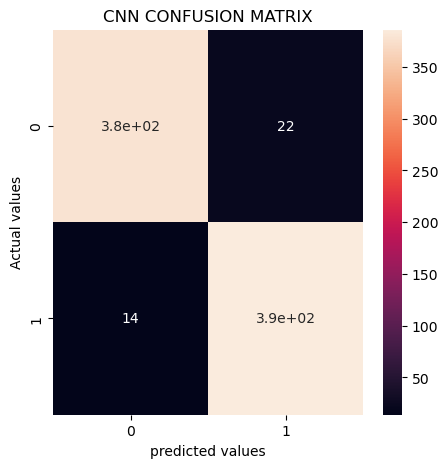

In [18]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [ ]:
def extract_hog_features1(images, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9):
    feats = []
    for img in images:
        hog_feat = hog(img, 
                       orientations=orientations, 
                       pixels_per_cell=pixels_per_cell, 
                       cells_per_block=cells_per_block, 
                       block_norm='L2-Hys', 
                       visualize=False, 
                       feature_vector=True)
        feats.append(hog_feat)
    return np.array(feats, dtype="float32")

X_train_hog1 = extract_hog_features1(x_train_rf.reshape(-1,200,200))
X_test_hog1  = extract_hog_features1(x_test_ml.reshape(-1,200,200))

print("HOG train shape:", X_train_hog1.shape)
print("HOG test shape :", X_test_hog1.shape)

scaler2 = StandardScaler()
X_train_scaled2 = scaler2.fit_transform(X_train_hog1)
X_test_scaled2 = scaler2.transform(X_test_hog1)

rf = RandomForestClassifier(
    n_estimators=500,       
    max_depth=None,        
    min_samples_split=4,    
    min_samples_leaf=2,      
    max_features="sqrt",    
    class_weight="balanced", 
    bootstrap=True,          
    random_state=42,
    n_jobs=-1                
)
rf.fit(X_train_scaled2 , y_train_rf)

pred2 = rf.predict(X_test_scaled2)

print("Train  Accuracy:", rf.score(X_train_scaled2 , y_train_rf))
print("RF (HOG) Test Accuracy:", accuracy_score(y_test, pred2))
print("\nClassification Report (HOG):\n", classification_report(y_test, pred2))


HOG train shape: (6400, 4356)
HOG test shape : (800, 4356)
Train  Accuracy: 1.0
RF (HOG) Test Accuracy: 0.9625

Classification Report (HOG):
               precision    recall  f1-score   support

           0       0.98      0.95      0.96       400
           1       0.95      0.98      0.96       400

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



In [20]:

conf_mat2=confusion_matrix(y_test,pred2)


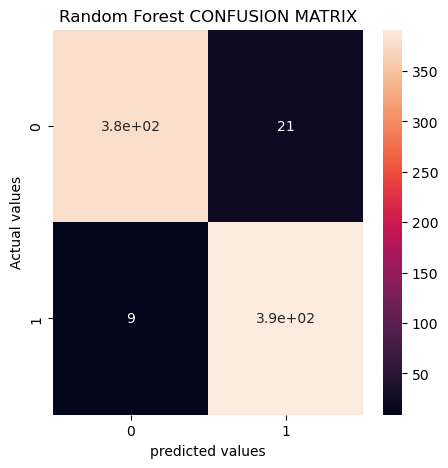

In [21]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [22]:
def extract_hog_features2(images, 
                             target_size=(128,128), 
                             pixels_per_cell=(8,8), 
                             cells_per_block=(2,2), 
                             orientations=9):
    feats = []
    for img in images:
        # Ensure grayscale
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Resize to consistent size
        img_resized = cv2.resize(img, target_size)

        # HOG feature extraction
        hog_feat = hog(img_resized,
                       orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       block_norm='L2-Hys',
                       visualize=False,
                       feature_vector=True)
        
        feats.append(hog_feat)

    return np.array(feats, dtype="float32")

# Reshape and prepare images
x_train_imgs2 = x_train_svm.reshape(-1, 200, 200)
x_test_imgs2  = x_test_ml.reshape(-1, 200, 200)

# Extract HOG features
X_train_hog2 = extract_hog_features2(x_train_imgs2)
X_test_hog2  = extract_hog_features2(x_test_imgs2)

print("Train shape:", X_train_hog2.shape)
print("Test shape :", X_test_hog2.shape)

# Train SVM
svm = SVC(kernel="rbf", C=3,  class_weight="balanced",gamma="scale", random_state=42)
svm.fit(X_train_hog2, y_train_svm)

# Predict
pred3 = svm.predict(X_test_hog2)

print("Train Accuracy:", svm.score(X_train_hog2, y_train_svm))
print("Test Accuracy:", accuracy_score(y_test, pred3))
print("\nClassification Report:\n", classification_report(y_test, pred3))



Train shape: (6400, 8100)
Test shape : (800, 8100)
Train Accuracy: 1.0
Test Accuracy: 0.97875

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       400
           1       0.98      0.97      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



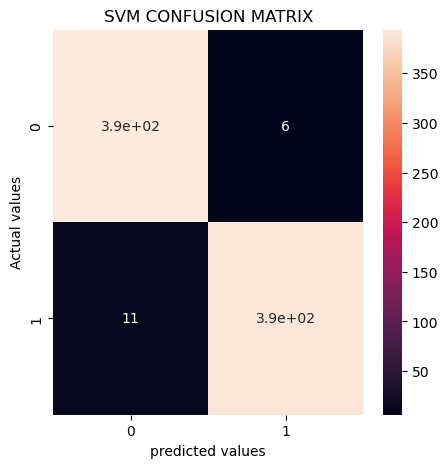

In [23]:
conf_mat3=confusion_matrix(y_test,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [24]:

def extract_hog_features4(images, pixels_per_cell=(8,8), cells_per_block=(2,2), orientations=9):
    all_feats = []
    for img in images:
        img = img.astype(np.float32)
        hog_feat = hog(img,
                       orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       block_norm='L2-Hys',
                       visualize=False,
                       feature_vector=True)
        all_feats.append(hog_feat)
    return np.array(all_feats, dtype=np.float32)


hog_train3= extract_hog_features4(x_train_knn)
hog_test3= extract_hog_features4(x_test_ml)
    



scaler4 = StandardScaler()
X_train_scaled4 = scaler4.fit_transform(hog_train3)
X_test_scaled4  = scaler4.transform(hog_test3)

knn = KNeighborsClassifier(n_neighbors=3, weights='distance',metric='manhattan')
knn.fit(X_train_scaled4, y_train_knn)

pred4 = knn.predict(X_test_scaled4 )

# -----------------------------
# 6. Evaluation
# -----------------------------
print("Train Accuracy:", knn.score(X_train_scaled4 , y_train_knn))
print("Test Accuracy:", accuracy_score(y_test, pred4))
print("\nClassification Report:\n", classification_report(y_test, pred4))


Train Accuracy: 1.0
Test Accuracy: 0.97375

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       400
           1       0.97      0.98      0.97       400

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



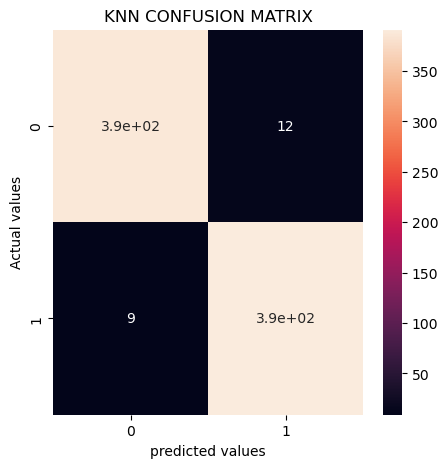

In [25]:
conf_mat4=confusion_matrix(y_test,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [26]:
def extract_wavelet_features5(images, wavelet="db1", level=2):
    """Extract wavelet features from MRI images"""
    all_feats = []
    for img in images:
        img = img.astype(np.float32)

        coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)

        feats = []
        for c in coeffs:
            if isinstance(c, tuple):
                for arr in c:
                    feats.extend(arr.ravel())
            else:
                feats.extend(c.ravel())

        all_feats.append(np.array(feats, dtype=np.float32))

    return np.array(all_feats, dtype=np.float32)

# -------------------------------
# 2. HOG Feature Extraction
# -------------------------------
def extract_hog_features5(images, pixels_per_cell=(16,16), cells_per_block=(2,2), orientations=9):
    """Extract HOG features from MRI images"""
    all_feats = []
    for img in images:
        img = img.astype(np.float32)

        hog_feat = hog(img,
                       orientations=orientations,
                       pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block,
                       block_norm='L2-Hys',
                       visualize=False,
                       feature_vector=True)
        all_feats.append(hog_feat)

    return np.array(all_feats, dtype=np.float32)

# -------------------------------
# 3. Combine Wavelet + HOG Features
# -------------------------------
def extract_combined_features5(images):
    wavelet_feats = extract_wavelet_features5(images)
    hog_feats     = extract_hog_features5(images)
    combined_feats = np.hstack([wavelet_feats, hog_feats])
    return combined_feats

# -------------------------------
# 5. Feature Extraction (Train/Test)
# -------------------------------
X_train_feats5 = extract_combined_features5(x_train_lr)
X_test_feats5  = extract_combined_features5(x_test_ml)

print("Feature shapes -> Train:", X_train_feats5.shape, "Test:", X_test_feats5.shape)

# -------------------------------
# 6. Scale Features & Train Logistic Regression
# -------------------------------


LogR = LogisticRegression(
    C=0.1,
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

LogR.fit(X_train_feats5, y_train_lr)

# -------------------------------
# 7. Evaluate on Internal Test Set
# -------------------------------
pred5  = LogR.predict(X_test_feats5 )

print("Train Accuracy:", LogR.score(X_train_feats5, y_train_lr))
print("Test  Accuracy:", accuracy_score(y_test, pred5))
print("\nClassification Report:\n", classification_report(y_test, pred5))


Feature shapes -> Train: (6400, 44356) Test: (800, 44356)
Train Accuracy: 1.0
Test  Accuracy: 0.955

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       400
           1       0.96      0.95      0.95       400

    accuracy                           0.95       800
   macro avg       0.96      0.95      0.95       800
weighted avg       0.96      0.95      0.95       800



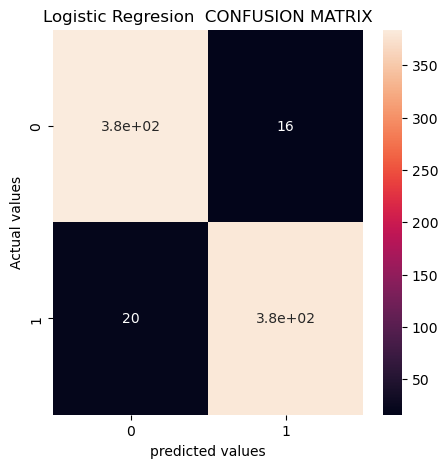

In [27]:
conf_mat5= confusion_matrix(y_test,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

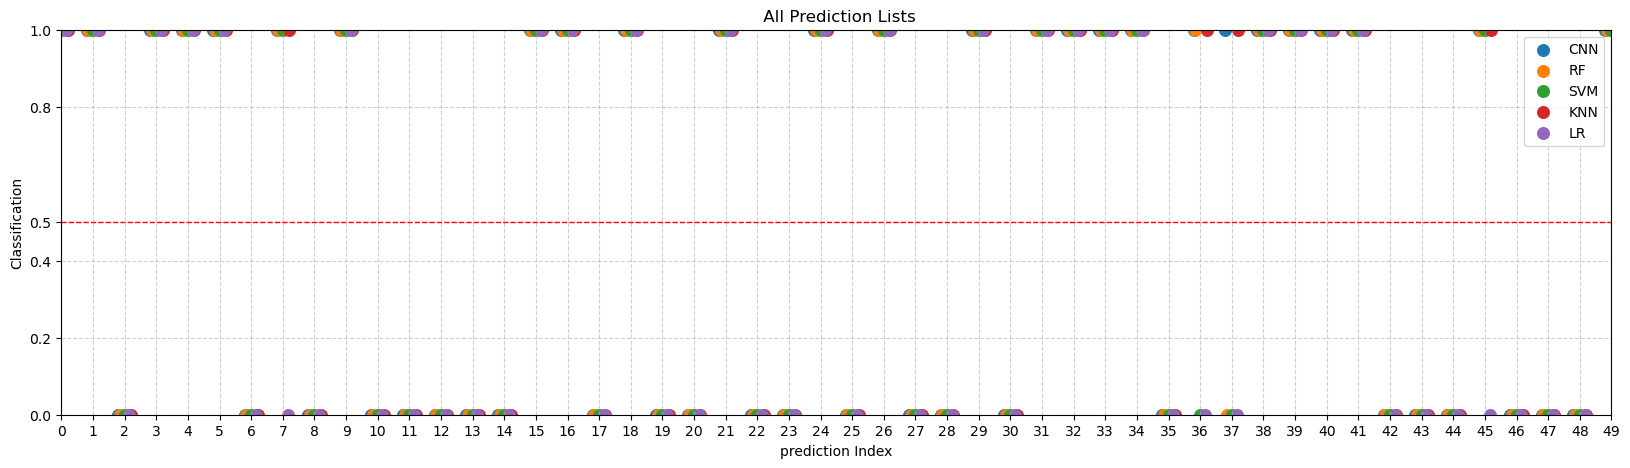

In [28]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [29]:
pp1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()

X_test_rf2  = extract_hog_features1(x_test_ml)
X_test_scaled_rf = scaler2.transform(X_test_rf2)


X_test_svm3  = extract_hog_features2(x_test_ml)


# Extract features & scale
X_ext_knn4 = extract_hog_features4(x_test_ml)
X_scaledknn4 = scaler4.transform(X_ext_knn4)

# Extract features & scale
X_ext_lr5 = extract_combined_features5(x_test_ml)



pp2=rf.predict(X_test_scaled_rf)
pp3=svm.predict(X_test_svm3)
pp4=knn.predict(X_scaledknn4)
pp5=LogR.predict(X_ext_lr5)

25/25 [==============================] - 3s 123ms/step


In [30]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [31]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[1, 1, 0, 1, 1, 1]


In [32]:
g=np.where(y_test != Ensemble_prediction)[0]
print(g)

[247 286 300 321 399 427 434 441 442 447 465 529 684 718 733 774]


In [33]:
print("Accuracy:", accuracy_score(y_test, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test, Ensemble_prediction))

Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       400
           1       0.98      0.98      0.98       400

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



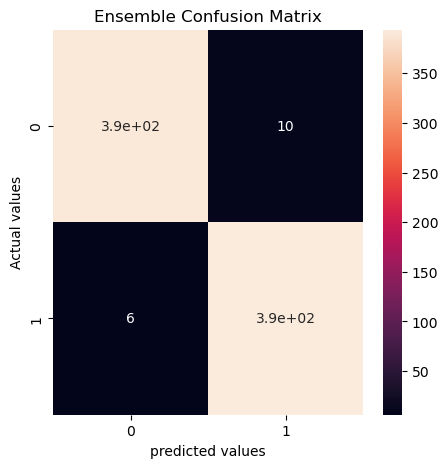

In [34]:
ensemble_confusion_matrix= confusion_matrix(y_test,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [35]:
img_path = '../external_pic/' 
classes_in_dir = {'Brain_tumor_test': 1, 'healty_test': 0}

X, Y, filenames = [], [], []

# Load images
for cls in classes_in_dir:
    folder_path = os.path.join(img_path, cls)
    for file in os.listdir(folder_path):
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Skipping {file}: cannot read image")
            continue
        img = cv2.resize(img, (200, 200))
        
        X.append(img)
        Y.append(classes_in_dir[cls])
        filenames.append(file)

x = np.array(X, dtype="float32")/255.0 
y = np.array(Y)


# --------------------
# Prepare all images for batch predictions
# --------------------
x_cnn = x.reshape(-1, 200, 200, 1)    
x_flat = x.reshape(len(x), 200,200)     

print("x_cnn shape:", x_cnn.shape)
print("x_flat shape:", x_flat.shape)



x_cnn shape: (90, 200, 200, 1)
x_flat shape: (90, 200, 200)


In [36]:
preds_cnn = (cnn.predict(x_cnn) > 0.5).astype(int).flatten()

X_test_external_rf = extract_hog_features1(x_flat)
X_test_ext_rf = scaler2.transform(X_test_external_rf)

X_test_external_svm = extract_hog_features2(x_flat)

X_external_feats4 = extract_hog_features4(x_flat)
X__external_knn_scaled = scaler4.transform(X_external_feats4)

X_external_feats5 = extract_combined_features5(x_flat)

preds_rf  = rf.predict(X_test_ext_rf)
preds_svm = svm.predict(X_test_external_svm )
preds_knn = knn.predict(X__external_knn_scaled)
preds_lr  = LogR.predict(X_external_feats5)

votes = preds_cnn + preds_rf + preds_svm + preds_knn + preds_lr
result_in_binary = (votes >= 3).astype(int)

results = []
count_tumor = np.sum(result_in_binary == 1)
count_healthy = np.sum(result_in_binary == 0)

for i, file in enumerate(filenames):
    final_label = "Tumor" if result_in_binary[i] == 1 else "Healthy"
    results.append((file, final_label))
    print(f"{file}: CNN={preds_cnn[i]}, RF={preds_rf[i]}, SVM={preds_svm[i]}, KNN={preds_knn[i]}, LR={preds_lr[i]} -> Final: {final_label}")

# --------------------
# Summary
# --------------------
print("\n=== Summary ===")
print("Ensemble Accuracy:", accuracy_score(y, result_in_binary))
print("Ground truth counts:\n", pd.Series(y).value_counts())
print(f"Total images processed: {len(results)}")
print(f"Tumor (predicted): {count_tumor}")
print(f"Healthy (predicted): {count_healthy}")

print("\n=== Individual Model Accuracies ===")
print("CNN Accuracy:", accuracy_score(y, preds_cnn))
print("RF Accuracy:", accuracy_score(y, preds_rf))
print("SVM Accuracy:", accuracy_score(y, preds_svm))
print("LR Accuracy:", accuracy_score(y, preds_lr))
print("KNN Accuracy:", accuracy_score(y, preds_knn))


3/3 [==============================] - 0s 130ms/step
PMA Meningiom (1).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (10).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (11).jpg: CNN=1, RF=1, SVM=1, KNN=0, LR=1 -> Final: Tumor
PMA Meningiom (12).jpg: CNN=1, RF=1, SVM=1, KNN=0, LR=1 -> Final: Tumor
PMA Meningiom (13).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (14).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (15).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (16).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (17).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (2).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (3).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (4).jpg: CNN=1, RF=1, SVM=0, KNN=0, LR=1 -> Final: Tumor
PMA Meningiom (42).jpg: CNN=1, RF=1, SVM=1, KNN=1, LR=1 -> Final: Tumor
PMA Meningiom (

In [37]:
img_path2 = r"D:\My Final Work\external_pic/h5.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


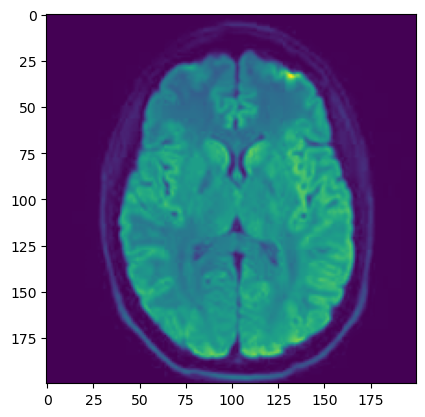

In [38]:
plt.imshow(pic1)

In [39]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [40]:
cnnpred.shape

(1, 200, 200, 1)

In [41]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 38ms/step


In [42]:
print(p11)

[0]


In [43]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [44]:
X_test_hog_rf=extract_hog_features1(p_2D.reshape(-1,200,200))
X_test_hog_svm=extract_hog_features2(p_2D.reshape(-1,200,200))

# Extract features & scale
X_external_feats4 = extract_hog_features4(p_2D.reshape(-1,200,200))
X__ext_one_knn = scaler4.transform(X_external_feats4)

# Extract features & scale
X_external_feats5 = extract_combined_features5(p_2D.reshape(-1,200,200))
X__ext_one_lr = scaler5.transform(X_external_feats5)


NameError: name 'scaler5' is not defined

In [ ]:
p22=rf.predict(X_test_hog_rf)
p33=svm.predict(X_test_hog_svm)
p44 = knn.predict(X__ext_one_knn)
p55=LogR.predict(X__ext_one_lr)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('KNN =',p44)
print('LogR =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [0]
KNN = [0]
LogR = [0]

 No Tumor
